Import Libraries

In [1]:
!pip install pmdarima

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

from pmdarima import auto_arima

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

import warnings
warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 40.6 MB/s eta 0:00:00


Load Dataset

In [2]:
df = pd.read_csv("METR-LA.csv")

df.rename(columns={'Unnamed: 0':'timestamp'}, inplace=True)

df['timestamp'] = pd.to_datetime(df['timestamp'])

df.set_index('timestamp', inplace=True)

df.head()

,773869,767541,767542,717447,717446,717445,773062,767620,737529,717816,...,772167,769372,774204,769806,717590,717592,717595,772168,718141,769373
timestamp,,,,,,,,,,,,,,,,,,,,,
2012-03-01 00:00:00,64.375000,67.625000,67.125000,61.500000,66.875000,68.750000,65.125,67.125,59.625000,62.750000,...,45.625000,65.500,64.500000,66.428571,66.875,59.375000,69.000000,59.250000,69.000000,61.875
2012-03-01 00:05:00,62.666667,68.555556,65.444444,62.444444,64.444444,68.111111,65.000,65.000,57.444444,63.333333,...,50.666667,69.875,66.666667,58.555556,62.000,61.111111,64.444444,55.888889,68.444444,62.875
2012-03-01 00:10:00,64.000000,63.750000,60.000000,59.000000,66.500000,66.250000,64.500,64.250,63.875000,65.375000,...,44.125000,69.000,56.500000,59.250000,68.125,62.500000,65.625000,61.375000,69.857143,62.000
2012-03-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000
2012-03-01 00:20:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000


In [3]:
print("Dataset shape:", df.shape)

df.info()

Dataset shape: (11868, 207)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11868 entries, 2012-03-01 00:00:00 to 2012-04-11 04:55:00
Columns: 207 entries, 773869 to 769373
dtypes: float64(207)
memory usage: 18.8 MB


In [4]:
df.replace(0, np.nan, inplace=True)

df = df.interpolate()

df = df.fillna(method='bfill')

df.head()

,773869,767541,767542,717447,717446,717445,773062,767620,737529,717816,...,772167,769372,774204,769806,717590,717592,717595,772168,718141,769373
timestamp,,,,,,,,,,,,,,,,,,,,,
2012-03-01 00:00:00,64.375000,67.625000,67.125000,61.500000,66.875000,68.750000,65.125000,67.125000,59.625000,62.750000,...,45.625000,65.500000,64.500000,66.428571,66.875000,59.375000,69.000000,59.250000,69.000000,61.875000
2012-03-01 00:05:00,62.666667,68.555556,65.444444,62.444444,64.444444,68.111111,65.000000,65.000000,57.444444,63.333333,...,50.666667,69.875000,66.666667,58.555556,62.000000,61.111111,64.444444,55.888889,68.444444,62.875000
2012-03-01 00:10:00,64.000000,63.750000,60.000000,59.000000,66.500000,66.250000,64.500000,64.250000,63.875000,65.375000,...,44.125000,69.000000,56.500000,59.250000,68.125000,62.500000,65.625000,61.375000,69.857143,62.000000
2012-03-01 00:15:00,61.777778,65.500000,62.555556,59.888889,66.777778,67.166667,63.222222,65.277778,63.583333,64.694444,...,43.416667,69.333333,60.444444,58.611111,67.416667,59.888889,65.305556,60.138889,69.571429,60.444444
2012-03-01 00:20:00,59.555556,67.250000,65.111111,60.777778,67.055556,68.083333,61.944444,66.305556,63.291667,64.013889,...,42.708333,69.666667,64.388889,57.972222,66.708333,57.277778,64.986111,58.902778,69.285714,58.888889


In [5]:
traffic = df[['773869','767541','767542']]

traffic.head()

,773869,767541,767542
timestamp,,,
2012-03-01 00:00:00,64.375000,67.625000,67.125000
2012-03-01 00:05:00,62.666667,68.555556,65.444444
2012-03-01 00:10:00,64.000000,63.750000,60.000000
2012-03-01 00:15:00,61.777778,65.500000,62.555556
2012-03-01 00:20:00,59.555556,67.250000,65.111111


<Figure size 1200x600 with 0 Axes>

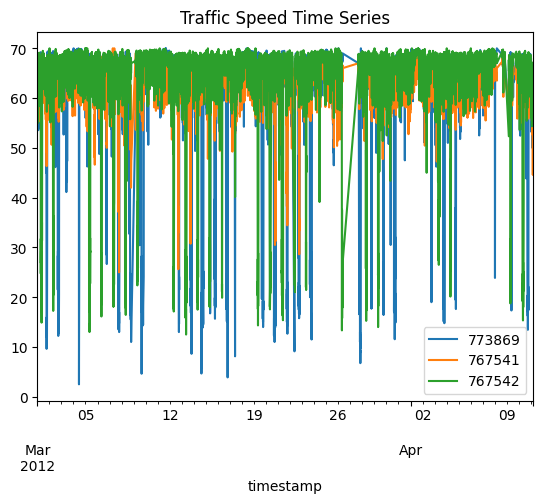

In [6]:
plt.figure(figsize=(12,6))

traffic.plot()

plt.title("Traffic Speed Time Series")

plt.show()

In [7]:
def adf_test(series):

    result = adfuller(series)

    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Critical Values:")

    for key,value in result[4].items():
        print(key, ":", value)

In [8]:
adf_test(traffic['773869'])

ADF Statistic: -15.34592821960905
p-value: 3.7761525383315707e-28
Critical Values:
1% : -3.4309016798573135
5% : -2.8617838138835703
10% : -2.5668997770686954


In [9]:
traffic = traffic.sort_index()

train_size = int(len(traffic) * 0.8)

train = traffic.iloc[:train_size]
test = traffic.iloc[train_size:]

print("Train size:", train.shape)
print("Test size:", test.shape)

print("Train last timestamp:", train.index[-1])
print("Test first timestamp:", test.index[0])

Train size: (9494, 3)
Test size: (2374, 3)
Train last timestamp: 2012-04-02 23:05:00
Test first timestamp: 2012-04-02 23:10:00


In [10]:
auto_model = auto_arima(

    train['773869'],

    start_p=0,
    start_q=0,

    max_p=5,
    max_q=5,

    seasonal=False,

    trace=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=105594.776, Time=0.11 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=93227.890, Time=0.81 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=52431.508, Time=0.38 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=52421.927, Time=2.67 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.43 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=52433.374, Time=1.13 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=52424.141, Time=4.04 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=52426.983, Time=0.58 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=0.41 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=52419.423, Time=17.14 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=52429.810, Time=15.92 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=52429.919, Time=3.62 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC

In [11]:
order = auto_model.order

arima_model = ARIMA(train['773869'], order=order)

arima_fit = arima_model.fit()

In [14]:
history_model = ARIMA(train['773869'], order=order)

history_fit = history_model.fit()

arima_predictions = []

for t in range(len(test)):

    yhat = history_fit.forecast()[0]

    arima_predictions.append(yhat)

    history_fit = history_fit.append(test['773869'].iloc[t:t+1], refit=False)

arima_predictions = pd.Series(arima_predictions, index=test.index)

In [20]:
actual = test['773869'][-len(predictions):]

rmse_arima = np.sqrt(mean_squared_error(actual, predictions))

mae_arima = mean_absolute_error(actual, predictions)

print("ARIMA RMSE:", rmse_arima)
print("ARIMA MAE:", mae_arima)

ARIMA RMSE: 11.196627854451897
ARIMA MAE: 5.940682681150692


In [21]:
var_model = VAR(train)

var_fit = var_model.fit(ic='aic')

lag_order = var_fit.k_ar

print("VAR Lag Order:", lag_order)

VAR Lag Order: 12


In [24]:
history = train.values

var_predictions = []

for t in range(len(test)):

    input_data = history[-lag_order:]

    forecast = var_fit.forecast(input_data, steps=1)

    var_predictions.append(forecast[0][0])

    history = np.vstack([history, test.iloc[t].values])

In [25]:
rmse_var = np.sqrt(mean_squared_error(test['773869'], var_predictions))

mae_var = mean_absolute_error(test['773869'], var_predictions)

print("VAR RMSE:", rmse_var)
print("VAR MAE:", mae_var)

VAR RMSE: 3.243537556124504
VAR MAE: 1.6780092526416013


In [26]:
results = pd.DataFrame({

    'Model':['ARIMA','VAR'],

    'RMSE':[rmse_arima, rmse_var],

    'MAE':[mae_arima, mae_var]

})

print(results)

   Model       RMSE       MAE
0  ARIMA  11.196628  5.940683
1    VAR   3.243538  1.678009


In [27]:
arima_residuals = test['773869'] - arima_predictions

In [28]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

res_scaled = scaler.fit_transform(arima_residuals.values.reshape(-1,1))

In [29]:
X = []
y = []

seq_len = 10

for i in range(seq_len, len(res_scaled)):

    X.append(res_scaled[i-seq_len:i])

    y.append(res_scaled[i])

X = np.array(X)
y = np.array(y)

print(X.shape)

(2364, 10, 1)


In [30]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

lstm_model = Sequential()

lstm_model.add(LSTM(64, return_sequences=True, input_shape=(seq_len,1)))

lstm_model.add(LSTM(32))

lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mse')

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
lstm_model.fit(

    X_train,
    y_train,

    epochs=20,
    batch_size=32,

    validation_data=(X_test,y_test)
)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0582 - val_loss: 0.0021
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0022 - val_loss: 0.0021
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0024 - val_loss: 0.0021
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0026 - val_loss: 0.0021
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0027 - val_loss: 0.0021
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0022 - val_loss: 0.0022
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0022 - val_loss: 0.0021
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0029 - val_loss: 0.0021
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0017 - val_loss: 0.0021
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0020 - val_loss: 0.0022
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0023 - val_loss: 0.0022
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0021 - va

In [33]:
lstm_pred_scaled = lstm_model.predict(X_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


In [34]:
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)

In [35]:
aligned_arima = arima_predictions[seq_len + split:]
aligned_actual = test['773869'][seq_len + split:]

In [36]:
hybrid_arima_lstm = aligned_arima.values + lstm_pred.flatten()

In [37]:
rmse_arima_lstm = np.sqrt(mean_squared_error(aligned_actual, hybrid_arima_lstm))

mae_arima_lstm = mean_absolute_error(aligned_actual, hybrid_arima_lstm)

print("ARIMA + LSTM RMSE:", rmse_arima_lstm)

print("ARIMA + LSTM MAE:", mae_arima_lstm)

ARIMA + LSTM RMSE: 3.3286431443707643
ARIMA + LSTM MAE: 2.0404766310015923


In [38]:
var_residuals = test['773869'] - var_predictions

In [39]:
res_scaled_var = scaler.fit_transform(var_residuals.values.reshape(-1,1))

In [41]:
hybrid_var_lstm = np.array(var_predictions[seq_len + split:]) + lstm_pred.flatten()

In [42]:
rmse_var_lstm = np.sqrt(mean_squared_error(aligned_actual, hybrid_var_lstm))

mae_var_lstm = mean_absolute_error(aligned_actual, hybrid_var_lstm)

print("VAR + LSTM RMSE:", rmse_var_lstm)

print("VAR + LSTM MAE:", mae_var_lstm)

VAR + LSTM RMSE: 3.3569502314821613
VAR + LSTM MAE: 2.0845359795198495


In [43]:
results = pd.DataFrame({

    'Model':['ARIMA','VAR','ARIMA+LSTM','VAR+LSTM'],

    'RMSE':[rmse_arima, rmse_var, rmse_arima_lstm, rmse_var_lstm],

    'MAE':[mae_arima, mae_var, mae_arima_lstm, mae_var_lstm]

})

print(results)

        Model       RMSE       MAE
0       ARIMA  11.196628  5.940683
1         VAR   3.243538  1.678009
2  ARIMA+LSTM   3.328643  2.040477
3    VAR+LSTM   3.356950  2.084536


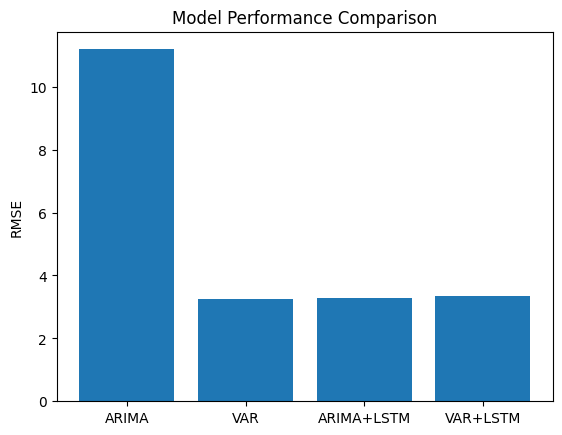

In [44]:
import matplotlib.pyplot as plt

models = ['ARIMA','VAR','ARIMA+LSTM','VAR+LSTM']
rmse = [11.19,3.24,3.29,3.36]

plt.bar(models, rmse)

plt.ylabel("RMSE")

plt.title("Model Performance Comparison")

plt.show()

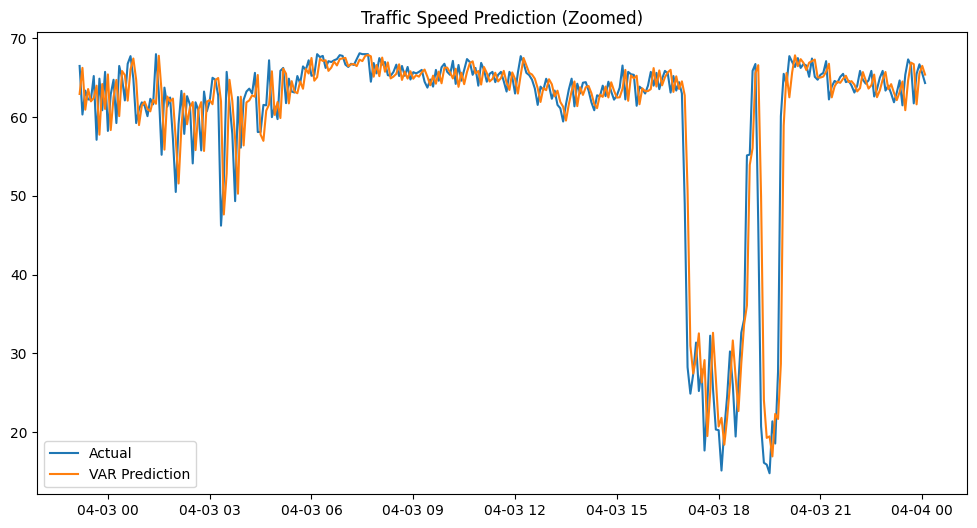

In [48]:
plt.figure(figsize=(12,6))

plt.plot(test.index[:300], test['773869'][:300], label="Actual")

plt.plot(test.index[:300], var_predictions[:300], label="VAR Prediction")

plt.legend()

plt.title("Traffic Speed Prediction (Zoomed)")

plt.show()

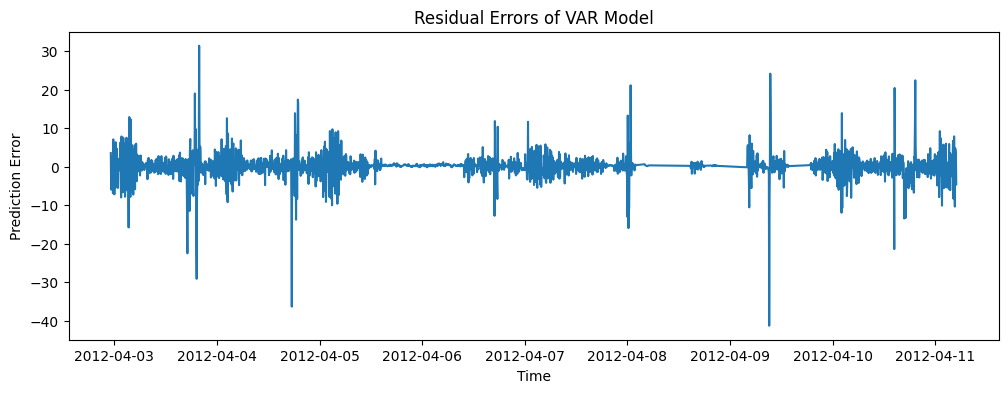

In [49]:
residuals = test['773869'] - var_predictions

plt.figure(figsize=(12,4))

plt.plot(residuals)

plt.title("Residual Errors of VAR Model")

plt.xlabel("Time")

plt.ylabel("Prediction Error")

plt.show()

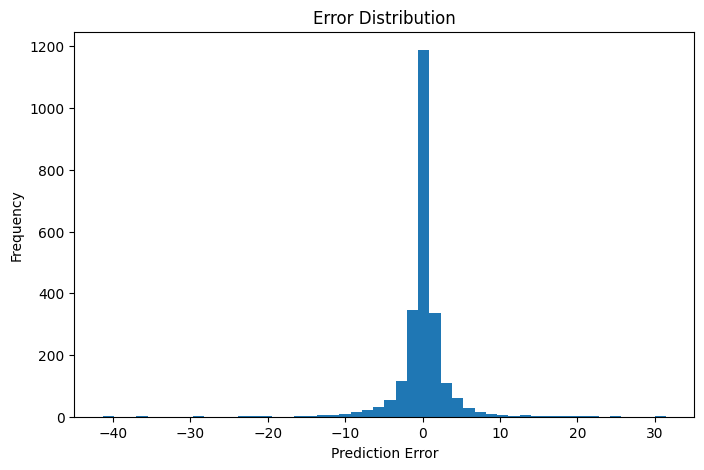

In [50]:
plt.figure(figsize=(8,5))

plt.hist(residuals, bins=50)

plt.title("Error Distribution")

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.show()

In [51]:
print(traffic.corr())

          773869    767541    767542
773869  1.000000  0.391828 -0.055088
767541  0.391828  1.000000  0.004370
767542 -0.055088  0.004370  1.000000
